In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import os

ai_path = '/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset'
real_path = '/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/real_dataset'
df = pd.DataFrame(columns=['file_name','class','is_ai'])

records = []
for state in os.listdir(ai_path):
    for file in os.listdir(os.path.join(ai_path, state)):
        records.append({
            "file_name": file,
            "class": state,
            "is_ai": 'True'
        })

for state in os.listdir(real_path):
    for file in os.listdir(os.path.join(real_path, state)):
        records.append({
            "file_name": file,
            "class": state,
            "is_ai": 'False'
        })

df = pd.DataFrame(records, columns=['file_name', 'class', 'is_ai']) 

# Step 1 - EDA

In [2]:
df

,file_name,class,is_ai
0,image-41.png,animals,True
1,image-48.png,animals,True
2,image-25.png,animals,True
3,image-45.png,animals,True
4,image-20.png,animals,True
...,...,...,...
990,people_109.jpg,people,False
991,people_20.jpg,people,False
992,people_34.jpg,people,False
993,people_32.jpg,people,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  995 non-null    object
 1   class      995 non-null    object
 2   is_ai      995 non-null    object
dtypes: object(3)
memory usage: 23.4+ KB


<Axes: title={'center': 'AI vs Real Image Distribution'}, ylabel='count'>

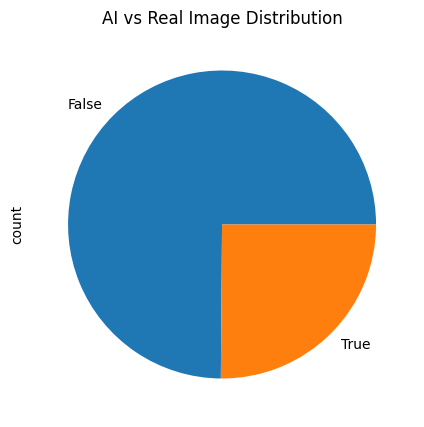

In [4]:
df['is_ai'].value_counts().plot.pie(figsize=(5, 5), title='AI vs Real Image Distribution')

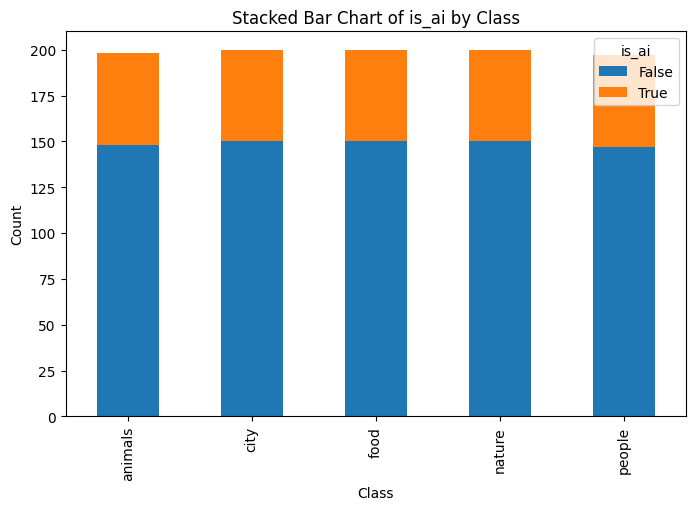

In [5]:
df_grouped = (
    df.groupby(['class', 'is_ai'])
    .size()
    .unstack(fill_value=0)
)

df_grouped.plot.bar(
    stacked=True,
    figsize=(8, 5),
    title='Stacked Bar Chart of is_ai by Class'
)
plt.ylabel('Count')
plt.xlabel('Class')
plt.show()

There are more real images than AI for every class

### Samples of AI images

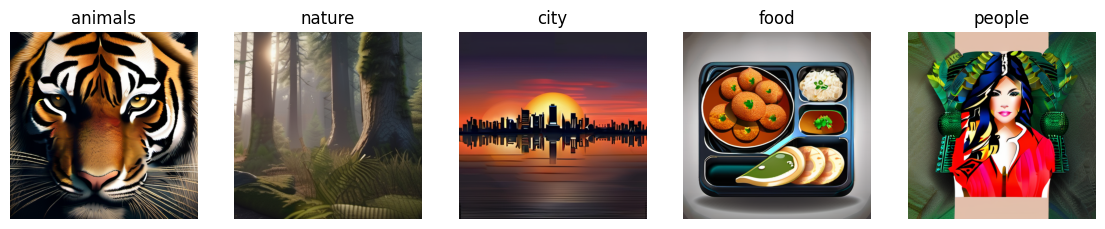

In [6]:
import random
from PIL import Image
f, axarr = plt.subplots(1, 5, figsize=(14,14))

i = 0
for class_name in os.listdir(ai_path):
    example = random.choice(os.listdir(ai_path + f'/{class_name}'))
    image = Image.open(ai_path + f'/{class_name}/{example}')
    axarr[i].set_axis_off()
    axarr[i].set_title(class_name)
    axarr[i].imshow(image)
    i+=1

### Samples of real images

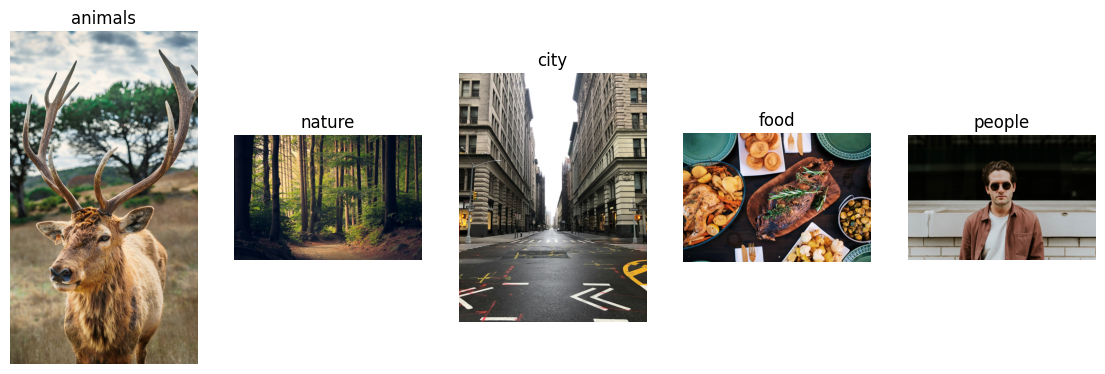

In [7]:
import random
from PIL import Image
f, axarr = plt.subplots(1, 5, figsize=(14,14))

i = 0
for class_name in os.listdir(real_path):
    example = random.choice(os.listdir(real_path + f'/{class_name}'))
    image = Image.open(real_path + f'/{class_name}/{example}')
    axarr[i].set_axis_off()
    axarr[i].set_title(class_name)
    axarr[i].imshow(image)
    i+=1

# Step 2 - Run DINOv2

In [8]:
from IPython.display import clear_output
!pip install --upgrade huggingface_hub
clear_output()

In [9]:
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "30"
from huggingface_hub import snapshot_download
model_id="facebook/dinov2-large"
snapshot_download(
    repo_id=model_id,     # model name on HF
    local_dir="/dino", # your target directory
)
clear_output()

In [10]:
from transformers import AutoImageProcessor, AutoModel
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, ckpt="/dino"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(ckpt)
        self.processor = AutoImageProcessor.from_pretrained(ckpt, use_fast=True)

    def forward(self, images):
        dev = next(self.parameters()).device
        inputs = self.processor(images=images, return_tensors="pt").to(dev)
        out = self.backbone(**inputs)
        feats = out.last_hidden_state[:, 0, :]
        return feats

model = Model().to('cuda:0').eval()

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

In [11]:
import torch
from torch.nn import functional as F

with torch.no_grad():
    embedding = model([image]) # random image we loaded previously
    image_features = F.normalize(embedding, dim=1)[-1]

DINOv2 provides 1024 features. Let's see if ML models can use it to distinguish between real and fake images.

In [12]:
image_features.shape

torch.Size([1024])

# Step 3 - Prepare dataset

In [13]:
import tqdm 

records = []

with torch.no_grad():
    for state in os.listdir(ai_path):
        for file in tqdm.tqdm(os.listdir(os.path.join(ai_path, state)), desc=f'Processing AI images for {state}'):
            image = Image.open(ai_path + f'/{state}/{file}')
            embedding = model([image]) 
            image_features = F.normalize(embedding, dim=1)[-1]
            vec = image_features.detach().cpu().numpy()
            record = {
                "file_name": file,
                "class": state,
                "is_ai": 'True',
            }
            record.update({f"emb_{i}": float(v) for i, v in enumerate(vec)})
            records.append(record)

    for state in os.listdir(real_path):
        for file in tqdm.tqdm(os.listdir(os.path.join(real_path, state)), desc=f'Processing real images for {state}'):
            image = Image.open(real_path + f'/{state}/{file}')
            embedding = model([image]) 
            image_features = F.normalize(embedding, dim=1)[-1]
            vec = image_features.detach().cpu().numpy()
            record ={
                "file_name": file,
                "class": state,
                "is_ai": 'False'
            }
            record.update({f"emb_{i}": float(v) for i, v in enumerate(vec)})
            records.append(record)

emb_cols = [f"emb_{i}" for i in range(len(vec))]
columns = ['file_name', 'class', 'is_ai'] + emb_cols
df = pd.DataFrame(records, columns=columns)

Processing real images for people: 100%|██████████| 147/147 [00:13<00:00, 11.21it/s]


In [14]:
emb_cols = [f"emb_{i}" for i in range(len(vec))]
columns = ['file_name', 'class', 'is_ai'] + emb_cols

df = pd.DataFrame(records, columns=columns)

In [15]:
df.head()

,file_name,class,is_ai,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_1014,emb_1015,emb_1016,emb_1017,emb_1018,emb_1019,emb_1020,emb_1021,emb_1022,emb_1023
0,image-41.png,animals,True,0.010003,0.000641,0.013395,-0.002226,0.000210,-0.026465,-0.019451,...,-0.047428,-0.014357,-0.035336,-0.014733,0.000903,0.028785,0.037568,-0.021956,-0.016751,-0.043417
1,image-48.png,animals,True,0.023503,0.066507,0.009338,-0.014073,-0.009299,0.005851,-0.027731,...,0.041443,0.007928,-0.013863,-0.008769,-0.013402,0.026196,-0.002422,-0.007480,0.003005,-0.029955
2,image-25.png,animals,True,0.010868,-0.008536,0.003110,0.034096,0.032190,0.000811,0.001261,...,-0.016827,0.015924,-0.060717,0.020402,-0.013905,0.041983,-0.021728,0.024198,0.011162,0.004660
3,image-45.png,animals,True,0.033671,0.067667,-0.001769,-0.003809,-0.011762,0.006771,-0.025980,...,0.022828,0.008742,-0.015348,-0.024575,-0.026552,0.010382,0.018443,-0.006362,-0.001435,-0.003600
4,image-20.png,animals,True,0.012437,-0.011262,0.003158,0.019561,-0.019344,0.011069,-0.002881,...,-0.013719,0.020186,-0.020472,-0.003008,-0.020243,0.015631,0.019062,-0.016788,-0.008028,0.025628


In [16]:
is_ai_encoding = {'True': 1, 'False': 0}
is_ai_decoding = {1: 'True', 0: 'False'}

df_ml = df.drop(columns=["file_name", "class"])
df_ml['is_ai'] = df_ml['is_ai'].replace(is_ai_encoding)
df_ml.head()

/tmp/ipykernel_23/3083469816.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ml['is_ai'] = df_ml['is_ai'].replace(is_ai_encoding)


,is_ai,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_1014,emb_1015,emb_1016,emb_1017,emb_1018,emb_1019,emb_1020,emb_1021,emb_1022,emb_1023
0,1,0.010003,0.000641,0.013395,-0.002226,0.000210,-0.026465,-0.019451,-0.024193,-0.011776,...,-0.047428,-0.014357,-0.035336,-0.014733,0.000903,0.028785,0.037568,-0.021956,-0.016751,-0.043417
1,1,0.023503,0.066507,0.009338,-0.014073,-0.009299,0.005851,-0.027731,0.045938,-0.019937,...,0.041443,0.007928,-0.013863,-0.008769,-0.013402,0.026196,-0.002422,-0.007480,0.003005,-0.029955
2,1,0.010868,-0.008536,0.003110,0.034096,0.032190,0.000811,0.001261,-0.003501,0.010493,...,-0.016827,0.015924,-0.060717,0.020402,-0.013905,0.041983,-0.021728,0.024198,0.011162,0.004660
3,1,0.033671,0.067667,-0.001769,-0.003809,-0.011762,0.006771,-0.025980,0.040842,-0.031057,...,0.022828,0.008742,-0.015348,-0.024575,-0.026552,0.010382,0.018443,-0.006362,-0.001435,-0.003600
4,1,0.012437,-0.011262,0.003158,0.019561,-0.019344,0.011069,-0.002881,-0.032692,-0.023567,...,-0.013719,0.020186,-0.020472,-0.003008,-0.020243,0.015631,0.019062,-0.016788,-0.008028,0.025628


In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(
    df_ml.drop(columns=["is_ai"]), 
    df_ml["is_ai"], 
    stratify=df_ml["is_ai"],
    test_size=0.2, 
    random_state=42
)

<Axes: xlabel='count', ylabel='is_ai'>

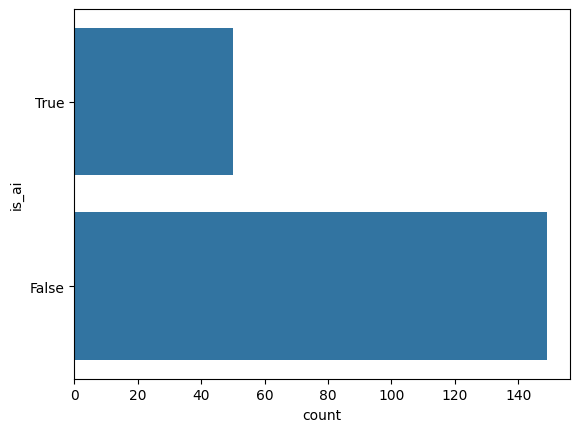

In [18]:
import seaborn as sns

sns.countplot(data=y_test.replace(is_ai_decoding))

In [19]:
print("We have {} training records".format(len(X_train)))
print("We have {} testing records".format(len(X_test)))

We have 796 training records
We have 199 testing records


We need to use cross validation hyperparameter tuning.


In [20]:
df_ml_input = df_ml.drop(columns=["is_ai"])
df_ml_output = df_ml["is_ai"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 4 - Hyperparameter tuning & Train ML

We will train KNN and XGBoost to compare classification performance.

In [21]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import clear_output

def objective(trial):
    params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 50),
            "weights":     trial.suggest_categorical("weights", ["uniform", "distance"]),
            "algorithm":   trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
            "leaf_size":   trial.suggest_int("leaf_size", 10, 60),
            "p":           trial.suggest_int("p", 1, 2),  # 1 = Manhattan, 2 = Euclidean
            "metric":      trial.suggest_categorical("metric", ["minkowski", "euclidean", "manhattan"]),
            }
    
    model = KNeighborsClassifier(**params)
    scores = cross_val_score(
        model, df_ml_input, df_ml_output,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )    
    return scores.mean()  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)
clear_output()

In [22]:
knn = KNeighborsClassifier(**study.best_params)
knn.fit(X_train, y_train)

KNeighborsClassifier(leaf_size=28, metric='manhattan', n_neighbors=18,
                     weights='distance')

In [23]:
from xgboost import XGBClassifier

def objective(trial):
    params = {
        'n_estimators'       : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'          : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'   : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'gamma'              : trial.suggest_float('gamma', 0.0, 1.0),
        'eval_metric'        : 'auc',
        'verbosity'          : 0
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(
        model, df_ml_input, df_ml_output,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )    
    return scores.mean()  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=True)
clear_output()

In [24]:
xg = XGBClassifier(**study.best_params)
xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8975979390992163, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.5713263500561281, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.027622892316157704,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=724, n_jobs=None,
              num_parallel_tree=None, ...)

# Step 5 - Evaluation

In [25]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, accuracy_score, auc
)

val_proba_knn = knn.predict_proba(X_test)[:, 1]
val_labels_knn = (val_proba_knn >= 0.5).astype(int)       

print('='*50)
print('📊 FULL EVALUATION REPORT FOR KNN')
print('='*50)
print(f'ROC-AUC Score  : {roc_auc_score(y_test, val_proba_knn):.5f}')
print(f'Accuracy       : {accuracy_score(y_test, val_labels_knn):.5f}')
print(f'F1 Score       : {f1_score(y_test, val_labels_knn):.5f}')
print(f'\n📋 Classification Report:')
val_labels_knn = pd.Series(val_labels_knn) 
print(classification_report(y_test.replace(is_ai_decoding), val_labels_knn.replace(is_ai_decoding)))

📊 FULL EVALUATION REPORT FOR KNN
ROC-AUC Score  : 0.98899
Accuracy       : 0.94975
F1 Score       : 0.90566

📋 Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.95      0.97       149
        True       0.86      0.96      0.91        50

    accuracy                           0.95       199
   macro avg       0.92      0.95      0.94       199
weighted avg       0.95      0.95      0.95       199



In [26]:
val_proba_xg = xg.predict_proba(X_test)[:, 1]
val_labels_xg = (val_proba_xg >= 0.5).astype(int)       

print('='*50)
print('📊 FULL EVALUATION REPORT FOR XGBoost')
print('='*50)
print(f'ROC-AUC Score  : {roc_auc_score(y_test, val_proba_xg):.5f}')
print(f'Accuracy       : {accuracy_score(y_test, val_labels_xg):.5f}')
print(f'F1 Score       : {f1_score(y_test, val_labels_xg):.5f}')
print(f'\n📋 Classification Report:')
val_labels_xg = pd.Series(val_labels_xg) 
print(classification_report(y_test.replace(is_ai_decoding), val_labels_xg.replace(is_ai_decoding)))

📊 FULL EVALUATION REPORT FOR XGBoost
ROC-AUC Score  : 0.99101
Accuracy       : 0.96985
F1 Score       : 0.93617

📋 Classification Report:
              precision    recall  f1-score   support

       False       0.96      1.00      0.98       149
        True       1.00      0.88      0.94        50

    accuracy                           0.97       199
   macro avg       0.98      0.94      0.96       199
weighted avg       0.97      0.97      0.97       199



/tmp/ipykernel_23/1748157931.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


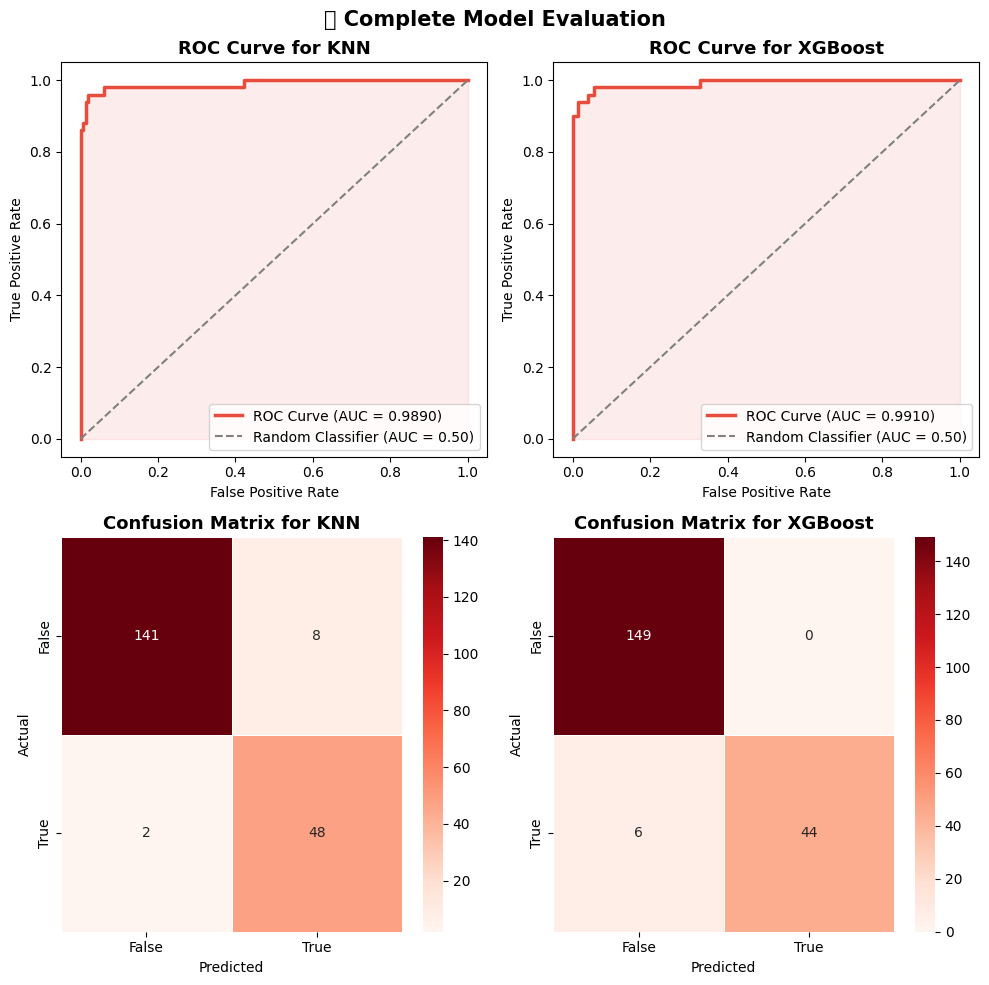

In [27]:
fig, axarr = plt.subplots(2, 2, figsize=(10, 10))
axes = axarr.ravel()

# ---- Plot 1: ROC Curve ----
fpr, tpr, _ = roc_curve(y_test, val_proba_knn)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#E74C3C', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
             label='Random Classifier (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve for KNN', fontweight='bold', fontsize=13)
axes[0].legend(loc='lower right')

cm = confusion_matrix(y_test, val_labels_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            ax=axes[2], linewidths=0.5,
            xticklabels=['False', 'True'],
            yticklabels=['False', 'True'],)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix for KNN', fontweight='bold', fontsize=13)

fpr, tpr, _ = roc_curve(y_test, val_proba_xg)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#E74C3C', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
             label='Random Classifier (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve for XGBoost', fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right')

cm = confusion_matrix(y_test, val_labels_xg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            ax=axes[3], linewidths=0.5,
            xticklabels=['False', 'True'],
            yticklabels=['False', 'True'],)
axes[3].set_xlabel('Predicted')
axes[3].set_ylabel('Actual')
axes[3].set_title('Confusion Matrix for XGBoost', fontweight='bold', fontsize=13)

plt.suptitle('📊 Complete Model Evaluation', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### To conclude, this notebook does demonstrate that using the DINO embedding model does allow ML to classify fake and real images very well.

Overall, XGBoost works better in all aspect. 